In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pumpkins = pd.read_csv('/Users/bilgeakar/ML-For-Beginners/2-Regression/data/US-pumpkins.csv')


#filtering the dataset to include only rows where the 'Package' column contains the word 'bushel'
pumpkins= pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
pumpkins.head()
#pumpkins.tail() last elements

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [56]:
print(len(pumpkins))
print(pumpkins.index.max()) # .tail diyince 1752-56 arası verdi merak ettim header'ı da sayıyormuş

415
1742


In [57]:
pumpkins.isnull().sum()


City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [58]:
# loc to extract needed columns
columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

print(pumpkins.head())

price = (pumpkins['Low Price'] + pumpkins['High Price'])/2
month = pd.DatetimeIndex(pumpkins['Date']).month


                 Package  Low Price  High Price     Date
70  1 1/9 bushel cartons       15.0        15.0  9/24/16
71  1 1/9 bushel cartons       18.0        18.0  9/24/16
72  1 1/9 bushel cartons       18.0        18.0  10/1/16
73  1 1/9 bushel cartons       17.0        17.0  10/1/16
74  1 1/9 bushel cartons       15.0        15.0  10/8/16


In [ ]:
# copy converted data into new dataframe
new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Price': price})


new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

print(new_pumpkins)

      Month               Package  Low Price  High Price  Price
70        9  1 1/9 bushel cartons      15.00        15.0  13.50
71        9  1 1/9 bushel cartons      18.00        18.0  16.20
72       10  1 1/9 bushel cartons      18.00        18.0  16.20
73       10  1 1/9 bushel cartons      17.00        17.0  15.30
74       10  1 1/9 bushel cartons      15.00        15.0  13.50
...     ...                   ...        ...         ...    ...
1738      9    1/2 bushel cartons      15.00        15.0  30.00
1739      9    1/2 bushel cartons      13.75        15.0  28.75
1740      9    1/2 bushel cartons      10.75        15.0  25.75
1741      9    1/2 bushel cartons      12.00        12.0  24.00
1742      9    1/2 bushel cartons      12.00        12.0  24.00

[415 rows x 5 columns]


Text(0, 0.5, 'Pumpkin Price')

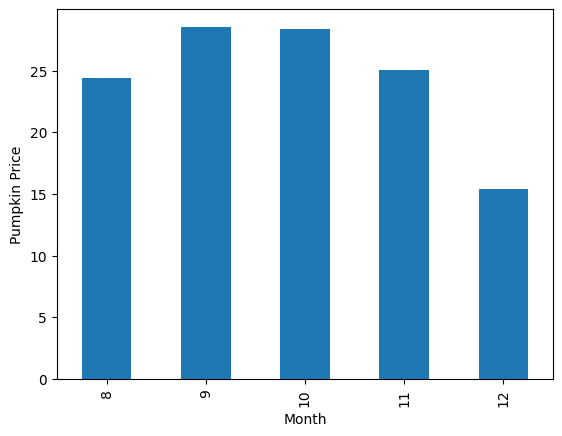

In [66]:
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")

In [65]:
# price = new_pumpkins.Price
# month = new_pumpkins.Month
# plt.scatter(price, month)
# plt.show()

In [64]:
#sns.relplot(x="Price", y="Month", kind="line", data=new_pumpkins)

<Axes: >

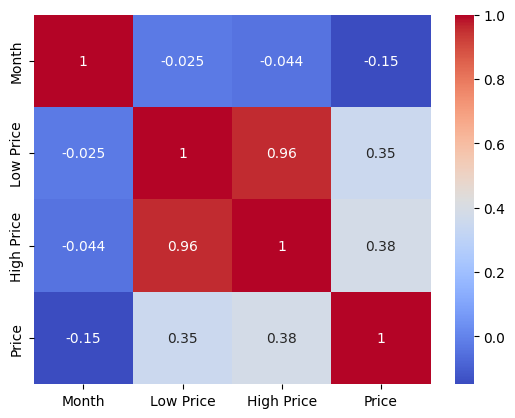

In [ ]:
# heatmaps Values close to 1 (or -1) mean the columns are strongly linearly correlated
correlations = new_pumpkins[['Month', 'Low Price', 'High Price', 'Price']].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

 Matplotlib gives you fine-grained control over every element of a chart and is the foundation almost every other Python plotting library builds on.

 Seaborn provides higher-level functions and attractive defaults for statistical charts, works directly with dataframes, and is often quicker for exploratory data analysis.